In [16]:
from model_ranking import (
    StandardEvalDataset,
    loader_classes,
    EvalDatasetConfig,
    load_h5,
    find_dataset_object_sizes,
)
import matplotlib.pyplot as plt
import numpy as np

In [2]:
ov_gt_path = "/scratch/talks/data/Ovules/GT2x/test/N_294_final_crop_ds2.h5"
raw = load_h5(ov_gt_path, "raw")
gt = load_h5(ov_gt_path, "label_with_ignore")

In [17]:
_, max_obj_size, _ = find_dataset_object_sizes(gt)
print(max_obj_size)

5867


In [7]:
fw_gt_path = "/scratch/talks/data/FlyWing/GT/test/per03.h5"
fw_raw = load_h5(fw_gt_path, "volumes/raw")
fw_gt = load_h5(fw_gt_path, "volumes/labels/expanded_cells_with_ignore")
print(fw_raw.shape, fw_gt.shape)

(160, 639, 765) (160, 639, 765)


In [18]:
_, max_obj_size, _ = find_dataset_object_sizes(fw_gt)
print(max_obj_size)

3387


In [3]:
raw.shape

(320, 960, 1000)

In [8]:
640-12

628

In [19]:
ovules_config = {
    "dataset": "StandardHDF5Dataset",
    "batch_size": 32,
    "num_workers": 8,
    "raw_internal_path": "raw",
    "label_internal_path": "label_with_ignore",
    "global_normalization": True,
    "global_percentiles": [5.0, 95.0],
    "output_dir": "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P_full/fw_model_Unet2/norm_50_950/gauss_a01-02/predictions",
    "test": {
        "file_paths": ["/scratch/talks/data/Ovules/GT2x/test/N_294_final_crop_ds2.h5"],
        "slice_builder": {
            "name": "SliceBuilder",
            "patch_shape": [1, 960, 1000],
            "stride_shape": [1, 960, 1000],
            "halo_shape": [0, 64, 64]
        },
        "transformer": {
            "raw": [
                {"name": "PercentileNormalizer"},
                {
                    "name": "AdditiveGaussianNoise",
                    "execution_probability": True,
                    "scale": [0.1, 0.2]
                },
                {
                    "name": "ToTensor",
                    "expand_dims": True
                }
            ]
        },
        "roi": None
    }
}

In [20]:
dataset_class = loader_classes(ovules_config['dataset'])
consis_datasets = dataset_class.create_datasets(ovules_config, 'test')

consis_dataset = consis_datasets[0]
print(len(consis_dataset))

2025-10-10 14:23:34,663 [MainThread] INFO HDF5Dataset - Loading test set from: /scratch/talks/data/Ovules/GT2x/test/N_294_final_crop_ds2.h5...
2025-10-10 14:23:34,664 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
Global mean: 28.59199455078125, global std: 58.52203523475804
2025-10-10 14:23:41,938 [MainThread] INFO Dataset - Slice builder config: {'name': 'SliceBuilder', 'patch_shape': [1, 960, 1000], 'stride_shape': [1, 960, 1000], 'halo_shape': [0, 64, 64]}
2025-10-10 14:23:41,942 [MainThread] INFO HDF5Dataset - Number of patches: 320
320


In [11]:
yaml_config = {
    "dataset": "StandardHDF5Dataset",
    "batch_size": 32,
    "num_workers": 8,
    "raw_internal_path": "volumes/raw",
    "label_internal_path": "volumes/labels/cells_with_ignore",
    "global_normalization": True,
    "global_percentiles": [5.0, 95.0],
    "output_dir": "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_FlyWing_gap/consistency/P_full/fw_model_Unet2/norm_50_950/gauss_a01-02/predictions",
    "test": {
        "file_paths": ["/scratch/talks/data/FlyWing/GT/test/per03.h5"],
        "slice_builder": {
            "name": "SliceBuilder",
            "patch_shape": [1, 639, 765],
            "stride_shape": [1, 639, 765],
            "halo_shape": [0, 0, 0]
        },
        "transformer": {
            "raw": [
                {"name": "PercentileNormalizer"},
                {
                    "name": "AdditiveGaussianNoise",
                    "execution_probability": True,
                    "scale": [0.1, 0.2]
                },
                {
                    "name": "ToTensor",
                    "expand_dims": True
                }
            ]
        },
        "roi": None
    }
}


In [12]:
dataset_class = loader_classes(yaml_config['dataset'])
consis_datasets = dataset_class.create_datasets(yaml_config, 'test')

consis_dataset = consis_datasets[0]
print(len(consis_dataset))

2025-10-10 14:17:38,691 [MainThread] INFO HDF5Dataset - Loading test set from: /scratch/talks/data/FlyWing/GT/test/per03.h5...
2025-10-10 14:17:38,691 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
Global mean: 69.46046953471007, global std: 48.11441160165768
2025-10-10 14:17:41,052 [MainThread] INFO Dataset - Slice builder config: {'name': 'SliceBuilder', 'patch_shape': [1, 639, 765], 'stride_shape': [1, 639, 765], 'halo_shape': [0, 0, 0]}
2025-10-10 14:17:41,054 [MainThread] INFO HDF5Dataset - Number of patches: 160
160


torch.Size([1, 1, 639, 765])


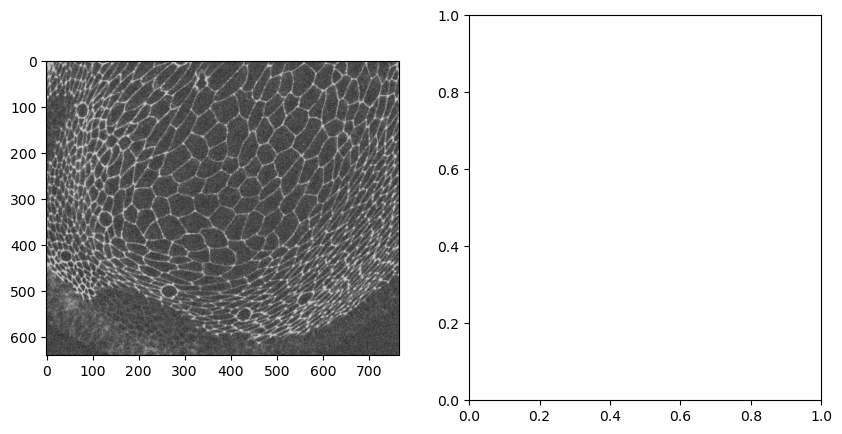

torch.Size([1, 1, 639, 765])


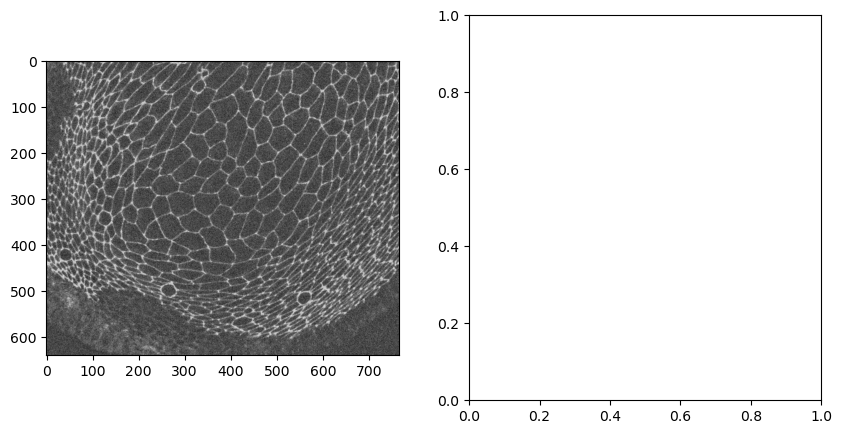

torch.Size([1, 1, 639, 765])


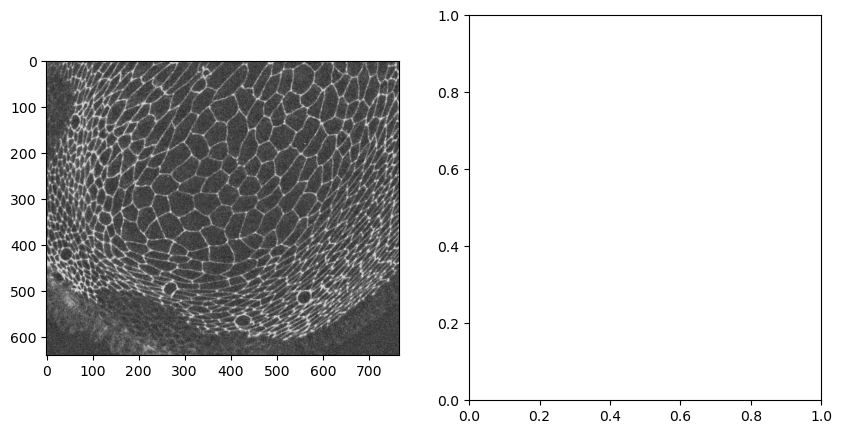

torch.Size([1, 1, 639, 765])


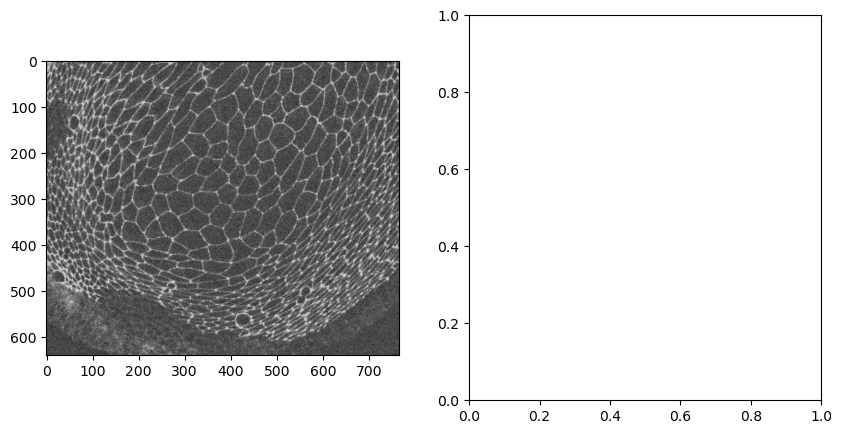

torch.Size([1, 1, 639, 765])


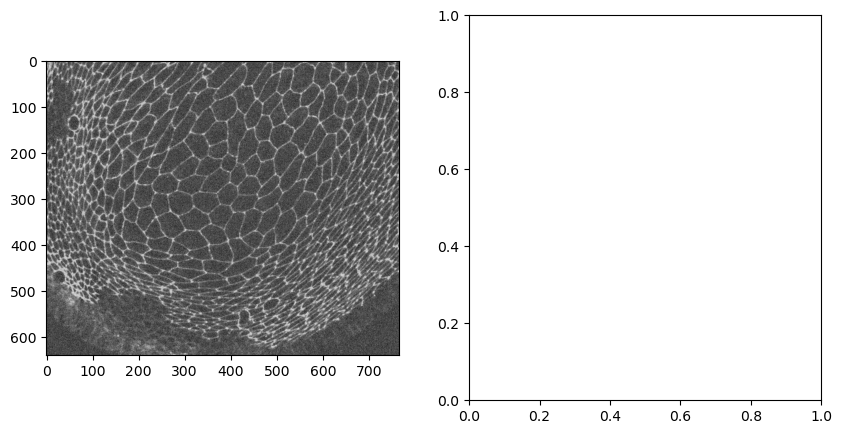

torch.Size([1, 1, 639, 765])


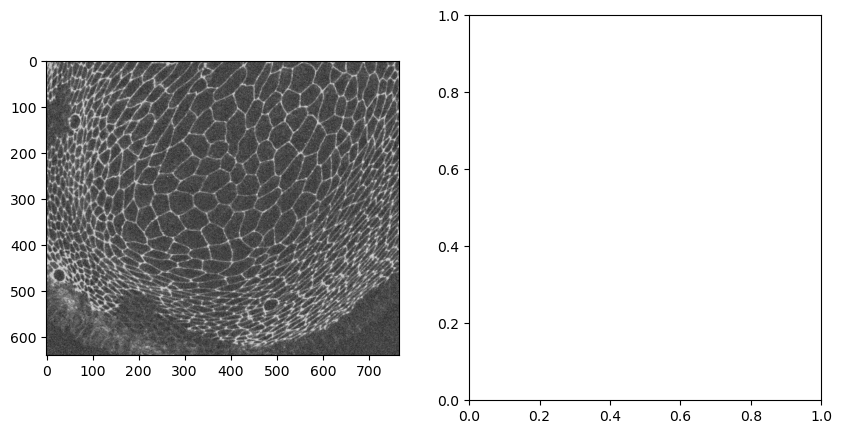

torch.Size([1, 1, 639, 765])


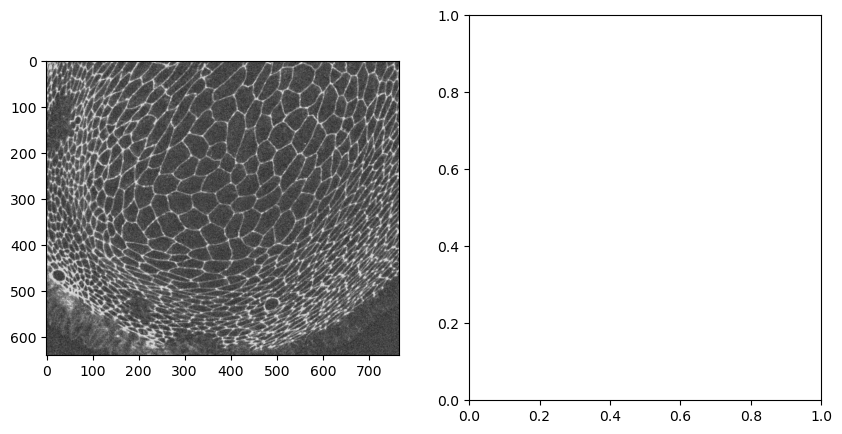

torch.Size([1, 1, 639, 765])


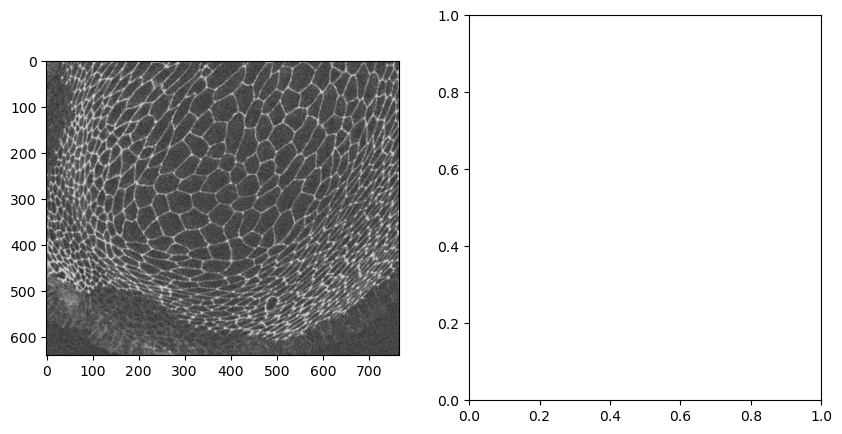

torch.Size([1, 1, 639, 765])


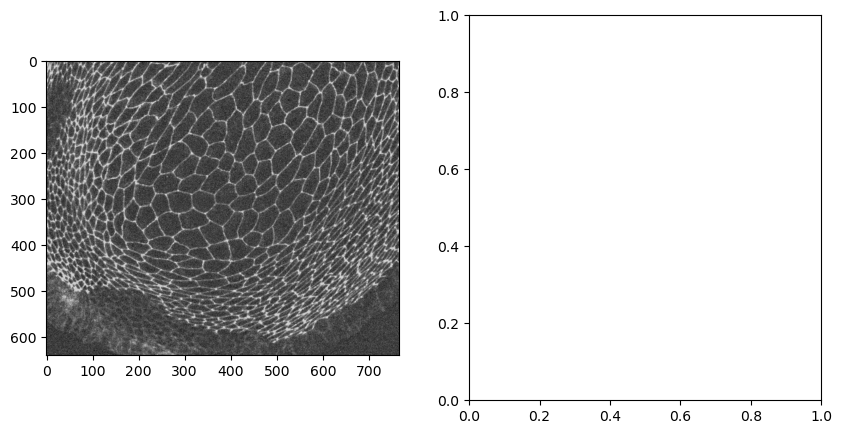

torch.Size([1, 1, 639, 765])


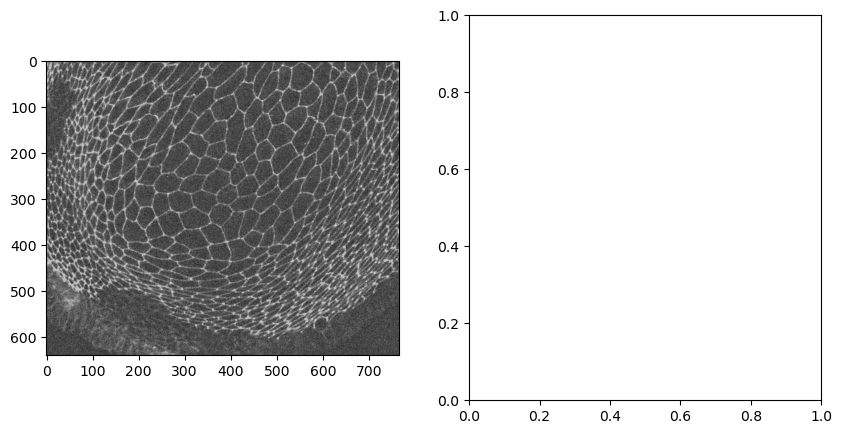

In [13]:
for i in range(10):
    raw_patch, _ = consis_dataset[i]
    print(raw_patch.shape)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(np.squeeze(raw_patch), cmap='gray')
    plt.show()